## Inferential Statistic for Laptop Price

    In this page will have been made paired hypothesis test for Actual_Price and Dicount_Price. Then will have been established a regression model and infered how much bought a desktop. Also, therefor will have been look at looked at independent categorical variables do have an impress.

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

In [2]:
# Dataframe
import pyodbc

server = r"(localdb)\MSSQLLocalDB"
database = "LaptopPriceAnalysis"
driver = "ODBC Driver 17 for SQL Server"

connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

print(connection_string)  

conn = pyodbc.connect(connection_string)
print("Connection Succesful")

DRIVER={ODBC Driver 17 for SQL Server};SERVER=(localdb)\MSSQLLocalDB;DATABASE=LaptopPriceAnalysis;Trusted_Connection=yes;
Connection Succesful


In [3]:
query = "SELECT * FROM dbo.Laptops_Final_Analysis"
df = pd.read_sql(query, conn)

df.head()


C:\Users\Yusuf\AppData\Local\Temp\ipykernel_14892\1377585449.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Laptop_ID,Discounted_Price,Actual_Price,Rating,Reviews,Brand,Core,SSD,Series,Processor,RAM,Storage
0,0,2034990.0,2580000.0,5.0,2.0,Apple,M1,None,MacBook,Apple M1,8GB,256GB SSD
1,1,2819990.0,3500000.0,43.0,5.0,Apple,M4,None,MacBook,None,None,None
2,2,2859990.0,3300000.0,NaN,NaN,ASUS,Ultra 7,16GB-512GB SSD,Zenbook,Intel Core Ultra 7,16GB,512GB SSD
3,3,2879990.0,3400000.0,NaN,NaN,Lenovo,Ultra 7,None,ThinkPad,Intel Core Ultra 7,16GB,512GB SSD
4,4,1469990.0,1750000.0,NaN,NaN,Lenovo,Ryzen 7,None,IdeaPad,AMD Ryzen 7,8GB,512GB SSD


## Paired Hypotesis Test
    Do Actual_Price and Discounted_Price have significant differents with each other or no? Look at that.
    Therefore will have used Z test. Because this sample bigger than 30 and variances are known.
    Z test in statmodels library. So it's been called and test's been made after that.

In [5]:
# Statsmodel library
from statsmodels.stats.weightstats import ztest

In [6]:
# Establishing sample

sample = df[["Discounted_Price", "Actual_Price"]].dropna()

## Null values were dropped from samples before the test. Because better result, null values shouldn't be.

In [8]:
sample["Difference"] = sample["Actual_Price"] - sample["Discounted_Price"]

In [9]:
z_stat, p_value = ztest(sample["Difference"], value=0)

In [10]:
print(f"Z-test: {z_stat:.4f}")
print(f"P-value: {p_value:.4e}")

Z-test: 28.0769
P-value: 1.8757e-173


H0 was rejected and between Discounted_Price and Actual_Price have significant distances. So, those discounteds are established really differences. Z-test is shown that this differences really high.

## Regression Test

In [11]:
## Before the regression test, it should be cleande outlier values.

data = df[["Actual_Price", "Discounted_Price"]].dropna().copy()

In [14]:
def remove_outliers(df, columns):
    mask = np.ones(len(df), dtype=bool)
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        col_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
        mask = mask & col_mask
    return df[mask]

In [15]:
clean_data = remove_outliers(data, ["Discounted_Price", "Actual_Price"])

In [19]:
## Regression Model

x = clean_data["Discounted_Price"]
y = clean_data["Actual_Price"]

In [20]:
import statsmodels.api as sm

In [22]:
X = sm.add_constant(x)

In [23]:
model = sm.OLS(y, X).fit()

In [24]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Actual_Price   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     6085.
Date:                Fri, 16 Jan 2026   Prob (F-statistic):          5.00e-191
Time:                        17:34:20   Log-Likelihood:                -3871.2
No. Observations:                 280   AIC:                             7746.
Df Residuals:                     278   BIC:                             7754.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             3.395e+05   3.67e+04  

## Interpretation:
    R-square so big. This mean is that, discounted price explains on actual price on sight.
    AIC and BIC scores support that result.
    This result has so small a std. error (0,000036...). So this is so significant result.

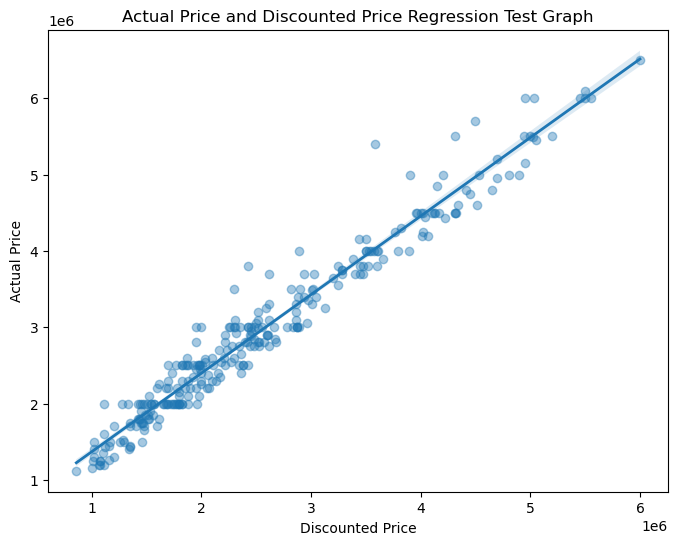

In [26]:
## Grafic Visualiton

plt.figure(figsize=(8, 6))
sbn.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 0.4},
    line_kws={"linewidth": 2}
)

plt.xlabel("Discounted Price")
plt.ylabel("Actual Price")
plt.title("Actual Price and Discounted Price Regression Test Graph")
plt.show()

## Interpretation:
    This graph is shown that, this result is so significant for discounted price and actual price

## Hardware Impress to Actual Price
    RAM, SSD, storage... harware specials how to impress Actual Price. It's been looked at. Therefore multiple regression test has been done.

In [27]:
features = ["Brand", "Core", "Series", "Processor", "RAM", "SSD", "Storage"]

In [29]:
df_model = df[features + ["Actual_Price"]].dropna().copy()

In [31]:
df_dummies = pd.get_dummies(
    df_model,
    columns=features,
    drop_first=True
)

In [32]:
X = df_dummies.drop("Actual_Price", axis=1)
y = df_dummies["Actual_Price"]

In [39]:
X = X.astype(float)

In [40]:
X = sm.add_constant(X)

In [41]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Actual_Price   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     7.486
Date:                Fri, 16 Jan 2026   Prob (F-statistic):           0.000122
Time:                        18:13:41   Log-Likelihood:                -685.85
No. Observations:                  49   AIC:                             1442.
Df Residuals:                      14   BIC:                             1508.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [44]:
y_pred = model.predict(X)

<function matplotlib.pyplot.show(close=None, block=None)>

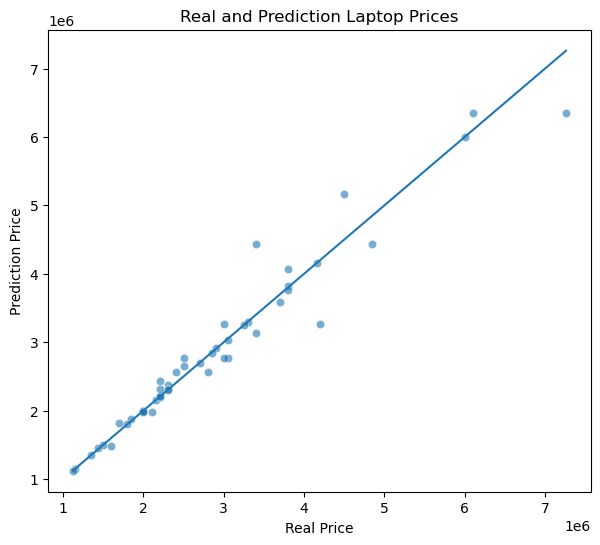

In [45]:
## Visualization

plt.figure(figsize=(7,6))
sbn.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Real Price")
plt.ylabel("Prediction Price")
plt.title("Real and Prediction Laptop Prices")
plt.show

## Interpretation
    Results and graph show that hardware impresses to the price that significant and powerfull. But some price can't be explained hardwares specials. However some brands hardware specials can't be explained to prices. Apple and Lenovo prices can't be explained y hardware speacials. Probably thes reason, the two brands ennoble and credible brands. But usually, hardware specials explaine to price.